In [1]:
import os
import pandas as pd

os.chdir('D:/vscode/aiffel/2026/09/14')

# 현재 이동한 위치 확인
print("현재 파이썬 작업 경로:", os.getcwd())

pd.set_option('display.unicode.east_asian_width', True)
pd.set_option('display.max_colwidth', None)

# 로컬 상대 경로 및 CSV 파일 설정
data_dir = "./data"
csv_path = os.path.join(data_dir, "ChatbotData.csv")

# Pandas로 CSV 데이터 로드
df = pd.read_csv(csv_path)

# 질문(Q)과 답변(A) 리스트 추출
raw_q = df['Q'].tolist()
raw_a = df['A'].tolist()

print(f"✅ 로컬 챗봇 데이터 로드 완료!")
print(f"전체 질문 수: {len(raw_q)}")
print(f"전체 답변 수: {len(raw_a)}\n")

# 데이터 샘플 확인
for i in range(3):
    print(f"[{i+1}] Q: {raw_q[i]}")
    print(f"    A: {raw_a[i]}\n")
    
print("--- 데이터셋 칼럼 및 구조 확인 ---")
print(df.head(5).to_string(justify='left'))
print("\n존재하는 칼럼 목록:", df.columns.tolist())

현재 파이썬 작업 경로: D:\vscode\aiffel\2026\09\14
✅ 로컬 챗봇 데이터 로드 완료!
전체 질문 수: 11823
전체 답변 수: 11823

[1] Q: 12시 땡!
    A: 하루가 또 가네요.

[2] Q: 1지망 학교 떨어졌어
    A: 위로해 드립니다.

[3] Q: 3박4일 놀러가고 싶다
    A: 여행은 언제나 좋죠.

--- 데이터셋 칼럼 및 구조 확인 ---
  Q                          A                     label
0                   12시 땡!    하루가 또 가네요.  0    
1        1지망 학교 떨어졌어     위로해 드립니다.  0    
2       3박4일 놀러가고 싶다  여행은 언제나 좋죠.  0    
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.  0    
4                 PPL 심하네   눈살이 찌푸려지죠.  0    

존재하는 칼럼 목록: ['Q', 'A', 'label']


제미나이는 Q A label 이라고 되어 있다고 말 해줬지만 그래도 눈으로 확인하는게 좋다는 생각에 출력하여 데이터의 구조를 확인합니다.

In [2]:
df['gpt_input'] = "[SOS] " + df['Q'].astype(str) + " [SEP] " + df['A'].astype(str) + " [EOS]"
gpt_data = df['gpt_input'].tolist()

print("\n변환된 GPT 입력 예시 (상위 3개):")
for idx, example in enumerate(gpt_data[:3], 1):
    print(f"[{idx}] {example}")


변환된 GPT 입력 예시 (상위 3개):
[1] [SOS] 12시 땡! [SEP] 하루가 또 가네요. [EOS]
[2] [SOS] 1지망 학교 떨어졌어 [SEP] 위로해 드립니다. [EOS]
[3] [SOS] 3박4일 놀러가고 싶다 [SEP] 여행은 언제나 좋죠. [EOS]


sos 질문 sep 답 eos 순으로 작성해줍니다.  
이렇게 작성하는 이유는 gpt 1 은 인코더가 없고 디코더만 있기 때문에 변경해줍니다.  
만약 9월10일때와 같이 인코더와 디코더가 같이 있는 상황이라면 이렇게 변경 안해도 됩니다.  
인코더와 디코더가 같이 있으면 소스 , 타겟으로 똑같이 처리해줍니다.  

In [3]:
import re
# 1. Q와 A가 완전히 동일한 중복 행 개수 확인
exact_duplicates = df.duplicated(subset=['Q', 'A']).sum()

# 2. Q(질문)만 중복되는 데이터 개수 확인
q_duplicates = df.duplicated(subset=['Q']).sum()

print(f"📊 전체 데이터 개수: {len(df)}개")
print(f"⚠️ Q와 A가 완전히 동일한 중복 데이터: {exact_duplicates}개")
print(f"⚠️ 질문(Q) 내용만 중복되는 데이터: {q_duplicates}개\n")

# 3. 만약 Q와 A가 완전히 같은 중복 데이터가 있다면 제거 (첫 번째 값 유지)
if exact_duplicates > 0:
    df = df.drop_duplicates(subset=['Q', 'A']).reset_index(drop=True)
    print(f"✅ 완전 중복 데이터 {exact_duplicates}개 제거 완료! (남은 데이터: {len(df)}개)")
else:
    print("✅ 완전 중복 데이터가 없습니다.")

def clean_text(text):
    text = str(text)
    # HTML 태그 제거
    text = re.sub(r'<[^>]+>', ' ', text)
    # HTML 특수문자 변환
    text = re.sub(r'&[a-zA-Z]+;', ' ', text)
    # 연속된 공백 축소 및 양끝 공백 제거
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Q와 A 컬럼에 정제 함수 적용
df['Q'] = df['Q'].apply(clean_text)
df['A'] = df['A'].apply(clean_text)

# 4. 정제된 df로 gpt_input 다시 생성
df['gpt_input'] = "[SOS] " + df['Q'].astype(str) + " [SEP] " + df['A'].astype(str) + " [EOS]"
gpt_data = df['gpt_input'].tolist()

print("\n--- 최종 전처리된 GPT 입력 예시 (상위 3개) ---")
for idx, example in enumerate(gpt_data[:3], 1):
    print(f"[{idx}] {example}")

📊 전체 데이터 개수: 11823개
⚠️ Q와 A가 완전히 동일한 중복 데이터: 73개
⚠️ 질문(Q) 내용만 중복되는 데이터: 161개

✅ 완전 중복 데이터 73개 제거 완료! (남은 데이터: 11750개)

--- 최종 전처리된 GPT 입력 예시 (상위 3개) ---
[1] [SOS] 12시 땡! [SEP] 하루가 또 가네요. [EOS]
[2] [SOS] 1지망 학교 떨어졌어 [SEP] 위로해 드립니다. [EOS]
[3] [SOS] 3박4일 놀러가고 싶다 [SEP] 여행은 언제나 좋죠. [EOS]


Q와 A에 동시에 중복이 되어있는 데이터만 삭제시켜주고 나머지 각 열의 중복 값은 다 가져갑니다.  
같은 질문을 해도 다른 대답이 나올 수 있고  
여러 질문을 해도 같은 대답이 나올 수 있기 때문입니다.  

In [4]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Metaspace
from tokenizers.decoders import Metaspace as MetaspaceDecoder
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(gpt_data, test_size=0.2, random_state=42)
print(f"총 데이터: {len(gpt_data)}개")
print(f" - Train 데이터: {len(train_data)}개")
print(f" - Valid 데이터: {len(val_data)}개")

# 1. 특수 토큰 목록 정의
special_tokens = ["[PAD]", "[UNK]", "[SOS]", "[EOS]", "[SEP]"]

# 2. BPE 토크나이저 모델 초기화 (UNK 토큰 지정)
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))

# 3. Pre-tokenizer 및 Decoder 설정
tokenizer.pre_tokenizer = Metaspace()
tokenizer.decoder = MetaspaceDecoder()

# 4. BPE 학습기(Trainer) 설정 (Vocab Size: 2000)
trainer = BpeTrainer(
    vocab_size=2000,
    min_frequency=2,
    special_tokens=special_tokens
)

# 5. 전처리된 gpt_data로 토크나이저 학습
# tokenizer.train_from_iterator(gpt_data, trainer=trainer)
tokenizer.train_from_iterator(train_data, trainer=trainer)

# 6. 토크나이저 패딩/자르기 자동화 설정
PAD_ID = tokenizer.token_to_id("[PAD]")
MAX_LEN = 64
tokenizer.enable_padding(pad_id=PAD_ID, pad_token="[PAD]", length=MAX_LEN)
tokenizer.enable_truncation(max_length=MAX_LEN)

tokenizer.save("gpt1_chatbot_tokenizer.json")
print(f"✅ BPE 토크나이저 학습 완료! Vocab Size: {tokenizer.get_vocab_size()}개")
print("특수 토큰 ID 확인:")
for token in special_tokens:
    print(f" - {token}: {tokenizer.token_to_id(token)}")

# 7. 사전 토큰화 적용 Dataset
class FastChatbotDataset(Dataset):
    def __init__(self, data_list, tokenizer):
        print("⚡ 데이터셋 사전 토큰화(Pre-tokenization) 진행 중...")
        # enable_padding/truncation이 설정되어 있어 encode_batch로 초고속 일괄 처리 가능
        encoded_batch = tokenizer.encode_batch(data_list)
        self.encoded_data = [e.ids for e in encoded_batch]
        print(f"✅ {len(self.encoded_data)}개 데이터 사전 토큰화 완료!")

    def __len__(self):
        return len(self.encoded_data)

    def __getitem__(self, idx):
        return torch.tensor(self.encoded_data[idx], dtype=torch.long)

# 8. Dataset 및 DataLoader 생성 테스트
train_dataset = FastChatbotDataset(train_data, tokenizer)
val_dataset = FastChatbotDataset(val_data, tokenizer)

# Train DataLoader는 shuffle=True, Valid DataLoader는 shuffle=False
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 샘플 데이터 Shape 검증
print(f"\n✅ Train DataLoader 배치 수: {len(train_loader)}")
print(f"✅ Valid DataLoader 배치 수: {len(val_loader)}")

총 데이터: 11750개
 - Train 데이터: 9400개
 - Valid 데이터: 2350개
✅ BPE 토크나이저 학습 완료! Vocab Size: 2000개
특수 토큰 ID 확인:
 - [PAD]: 0
 - [UNK]: 1
 - [SOS]: 2
 - [EOS]: 3
 - [SEP]: 4
⚡ 데이터셋 사전 토큰화(Pre-tokenization) 진행 중...
✅ 9400개 데이터 사전 토큰화 완료!
⚡ 데이터셋 사전 토큰화(Pre-tokenization) 진행 중...
✅ 2350개 데이터 사전 토큰화 완료!

✅ Train DataLoader 배치 수: 294
✅ Valid DataLoader 배치 수: 74


데이터셋에서 미리 토크나이저 진행을 시작하여 학습,테스트 때 cpu gpu 이동을 막아줘서 시간을 절약합니다.  

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch Version:", torch.__version__)
print("Device:", device)

# GPU가 사용 가능할 때, 어떤 GPU 기종인지 출력
if device.type == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))

PyTorch Version: 2.5.1+cu121
Device: cuda
GPU Name: NVIDIA GeForce RTX 3060 Ti


In [6]:
import torch
import torch.nn as nn

class LearnablePositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_len=64, dropout=0.1):
        super().__init__()
        # 수학식이 아닌, 단어 임베딩처럼 위치 정보도 학습하도록 nn.Embedding 사용
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        seq_len = x.size(1)
        
        # 0부터 seq_len - 1까지의 위치 인덱스 생성 및 현재 디바이스 할당
        positions = torch.arange(seq_len, dtype=torch.long, device=x.device)
        
        # 입력 텐서(단어 임베딩)에 위치 임베딩 더하기
        x = x + self.pos_emb(positions)
        
        return self.dropout(x)

In [7]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model은 num_heads로 나누어 떨어져야 합니다."
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, padding_mask=None):
        # GPT는 Decoder-Only 구조이므로 Q, K, V가 모두 동일한 x에서 들어옵니다.
        batch_size, seq_len, _ = x.size()
        
        # 1. Q, K, V 분할 [batch_size, num_heads, seq_len, d_k]
        q = self.W_q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        k = self.W_k(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        v = self.W_v(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        
        # 2. Scaled Dot-Product Attention 계산
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)

        # 3. Causal Mask (미래 토큰 마스킹) 생성 -> 대각선 아래쪽만 1, 위쪽은 0
        causal_mask = torch.tril(torch.ones((seq_len, seq_len), device=x.device)).bool()
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(1) # [1, 1, seq_len, seq_len]

        # 4. Padding Mask가 있다면 Causal Mask와 결합 (AND 연산)
        if padding_mask is not None:
            if padding_mask.dim() == 2:
                # [batch_size, seq_len] -> [batch_size, 1, 1, seq_len]
                padding_mask = padding_mask.unsqueeze(1).unsqueeze(2)
            combined_mask = causal_mask & (padding_mask != 0)
        else:
            combined_mask = causal_mask

        # 5. 마스킹 적용 (0인 위치에 매우 작은 음수값 부여)
        scores = scores.masked_fill(combined_mask == 0, -1e4)

        # 6. Softmax 및 Dropout
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # 7. Context Vector 계산 및 병합
        context = torch.matmul(attn_weights, v)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        
        output = self.out_proj(context)
        return output, attn_weights

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))

In [9]:
import torch
import torch.nn as nn

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(DecoderLayer, self).__init__()
        
        # 1. Masked Self-Attention 및 FFN (Cross-Attention 제거)
        self.self_attn = MultiHeadAttention(d_model=d_model, num_heads=num_heads, dropout=dropout)
        self.ffn = PositionwiseFeedForward(d_model=d_model, d_ff=d_ff, dropout=dropout)
        
        # 2. LayerNorm 및 Dropout (cross_attn용 norm2, dropout2 제거)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, padding_mask=None):
        # --- 서브레이어 1: Masked Self-Attention (Post-LN 기준) ---
        attn_out, self_attn_weights = self.self_attn(x, padding_mask=padding_mask)
        x = self.norm1(x + self.dropout1(attn_out))
        
        # --- 서브레이어 2: Position-wise Feed-Forward ---
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))
        
        # cross_attn_weights가 없어졌으므로 self_attn_weights만 반환하거나 x만 반환
        return x

In [10]:
import torch
import torch.nn as nn

class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len=64, dropout=0.1, pad_idx=0):
        super(Decoder, self).__init__()
        self.d_model = d_model
        
        # 1. 단어 임베딩
        self.tok_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        
        # 2. 학습 가능한 위치 임베딩 (LearnablePositionalEmbedding 교체)
        self.pos_encoding = LearnablePositionalEmbedding(d_model=d_model, max_len=max_len, dropout=dropout)
        
        # 3. GPT-1용 DecoderLayer 쌓기
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # 4. Post-LN 최종 정규화
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, padding_mask=None):
        # 1. 단어 임베딩 통과 (Scale 곱셈 제거)
        out = self.tok_embedding(x)
        
        # 2. 위치 임베딩 더하기 및 Dropout 적용
        out = self.pos_encoding(out)

        # 3. N개의 DecoderLayer 순차 통과 (enc_src, cross_attn 수신 및 반환 코드 제거)
        for layer in self.layers:
            out = layer(out, padding_mask=padding_mask)

        # 4. 최종 LayerNorm 적용
        out = self.norm(out)
        return out # [batch_size, seq_len, d_model]

In [11]:
import torch
import torch.nn as nn

class GPT1(nn.Module):
    def __init__(self, vocab_size, d_model=512, num_layers=12, num_heads=8, d_ff=2048, max_len=512, dropout=0.1, pad_idx=0):
        super(GPT1, self).__init__()
        self.pad_idx = pad_idx

        # 1. 인코더 제거, Decoder 전용으로 구성
        self.decoder = Decoder(
            vocab_size=vocab_size, 
            d_model=d_model, 
            num_layers=num_layers, 
            num_heads=num_heads, 
            d_ff=d_ff, 
            max_len=max_len, 
            dropout=dropout, 
            pad_idx=pad_idx
        )
        
        # 2. 최종 Projection Head (LM Head)
        self.lm_head = nn.Linear(d_model, vocab_size)
        
        # 3. Weight Tying (디코더 임베딩 가중치와 LM Head 가중치 공유)
        self.lm_head.weight = self.decoder.tok_embedding.weight

    def forward(self, x):
        # x shape: [batch_size, seq_len]
        # (패딩 마스크나 Causal 마스크는 내부 어텐션 블록에서 처리하므로 x만 입력으로 받습니다)
        
        # 디코더 통과 -> [batch_size, seq_len, d_model]
        dec_out = self.decoder(x)
        
        # 최종 단어 예측 Logits 반환 -> [batch_size, seq_len, vocab_size]
        output = self.lm_head(dec_out)
        
        return output

In [12]:
import os
import torch
from torch.utils.data import DataLoader

# 1. GPT-1 전용 안전한 배치 패딩 클래스 (단일 시퀀스용)
class GPT1PadCollate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        # batch는 [input_ids_1, input_ids_2, ...] 형태로 들어온다고 가정합니다.
        # 만약 튜플 형태로 들어온다면 batch = [item[0] for item in batch] 처럼 처리할 수 있습니다.
        
        # 텐서 형태로 변환 후 패딩
        batch_tensors = [torch.tensor(seq, dtype=torch.long) for seq in batch]
        padded_batch = torch.nn.utils.rnn.pad_sequence(
            batch_tensors, 
            batch_first=True, 
            padding_value=self.pad_idx
        )
        return padded_batch

# 2. 패딩 토큰 인덱스 가져오기 (단일 토크나이저 기준)
pad_idx = tokenizer.token_to_id("[PAD]")
pad_collate = GPT1PadCollate(pad_idx=pad_idx)

# 3. DataLoader 고속화 설정 (Windows 환경 고려 num_workers=0 유지 아주 좋습니다!)
BATCH_SIZE = 64
NUM_WORKERS = 0  # Windows Jupyter 환경 안정성을 위해 0 유지

train_dataloader = DataLoader(
    train_dataset,  # Q+A가 하나로 합쳐진 GPT 전용 Dataset
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=pad_collate,
    num_workers=NUM_WORKERS, 
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=pad_collate,
    num_workers=NUM_WORKERS, 
    pin_memory=True
)

print(f"🚀 GPT-1용 고속 DataLoader 생성 완료! (PAD ID: {pad_idx})")

🚀 GPT-1용 고속 DataLoader 생성 완료! (PAD ID: 0)


In [13]:
# 1. 단어장 크기 및 패딩 토큰 ID 설정 (단일 단어장 기준)
VOCAB_SIZE = tokenizer.get_vocab_size()
PAD_IDX = tokenizer.token_to_id("[PAD]")  # PAD_IDX 변수 정의

# 2. 모델 하이퍼파라미터 (GPT-1 스펙 또는 실습용 설정)
D_MODEL = 512
NUM_LAYERS = 6   # 또는 원본 논문처럼 12
NUM_HEADS = 8
D_FF = 2048
DROPOUT = 0.1
MAX_LEN = 64     # 토크나이저 설정에 맞춘 최대 시퀀스 길이

# 3. GPT1 모델 객체 생성 (우리가 위에서 리팩토링한 클래스 이름 기준)
model = GPT1(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    max_len=MAX_LEN,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
).to(device)

print(f"🚀 GPT-1 모델 생성 및 {device} 할당 완료!")
print(f"적용된 VOCAB_SIZE: {VOCAB_SIZE} | PAD_IDX: {PAD_IDX}")

🚀 GPT-1 모델 생성 및 cuda 할당 완료!
적용된 VOCAB_SIZE: 2000 | PAD_IDX: 0


In [15]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# 1. 디렉토리 설정 및 가중치 초기화
save_dir = "./checkpoints"
os.makedirs(save_dir, exist_ok=True)

def weights_init(m):
    if hasattr(m, 'weight') and m.weight.dim() > 1:
        nn.init.xavier_uniform_(m.weight.data)

model.apply(weights_init)
model = model.to(device)

# 2. 패딩 토큰 및 손실 함수 / 옵티마이저 설정
PAD_IDX = tokenizer.token_to_id("[PAD]")
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# GPT-1 학습용 AdamW 옵티마이저
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)

# 3. 1 에포크 학습 함수 (Causal LM 방식)
scaler = torch.cuda.amp.GradScaler()

def train_epoch(model, dataloader, optimizer, criterion, device, epoch, total_epochs):
    model.train()
    epoch_loss = 0
    pbar = tqdm(dataloader, desc=f"Epoch [{epoch}/{total_epochs}] Train", leave=False)

    for batch in pbar:
        # 단일 시퀀스 배치 가져오기
        batch = batch.to(device, non_blocking=True)
        
        # Causal LM: 입력을 한 칸씩 밀어서 Target 생성
        inputs = batch[:, :-1]
        targets = batch[:, 1:]

        optimizer.zero_grad()

        # Mixed Precision 연산 적용
        with torch.cuda.amp.autocast():
            logits = model(inputs)  # GPT-1은 inputs만 받음
            loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        loss_val = loss.item()
        epoch_loss += loss_val
        pbar.set_postfix({'loss': f'{loss_val:.4f}'})

    return epoch_loss / len(dataloader)


# 4. 1 에포크 검증 함수
def evaluate(model, dataloader, criterion, device, epoch, total_epochs):
    model.eval()
    epoch_loss = 0
    pbar = tqdm(dataloader, desc=f"Epoch [{epoch}/{total_epochs}] Eval ", leave=False)

    with torch.no_grad():
        for batch in pbar:
            batch = batch.to(device, non_blocking=True)
            inputs = batch[:, :-1]
            targets = batch[:, 1:]

            logits = model(inputs)
            loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

            epoch_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return epoch_loss / len(dataloader)


# 5. 학습 및 검증 실행 Loop
NUM_EPOCHS = 30
print("=== GPT-1 Causal Language Modeling Pre-training 시작 ===")

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_epoch(model, train_dataloader, optimizer, criterion, device, epoch, NUM_EPOCHS)
    val_loss = evaluate(model, val_dataloader, criterion, device, epoch, NUM_EPOCHS)
    
    # 체크포인트 저장
    checkpoint_path = os.path.join(save_dir, f"gpt1_epoch_{epoch}.pt")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss
    }, checkpoint_path)
    
    print(f" [ Epoch {epoch:02d}/{NUM_EPOCHS} ] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("✅ GPT-1 사전학습 및 체크포인트 저장 완료!")

C:\Users\User\AppData\Local\Temp\ipykernel_25192\4185573182.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


=== GPT-1 Causal Language Modeling Pre-training 시작 ===


Epoch [1/30] Train:   0%|          | 0/147 [00:00<?, ?it/s]C:\Users\User\AppData\Local\Temp\ipykernel_25192\1293289403.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch_tensors = [torch.tensor(seq, dtype=torch.long) for seq in batch]
C:\Users\User\AppData\Local\Temp\ipykernel_25192\4185573182.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


 [ Epoch 01/30 ] | Train Loss: 5.8434 | Val Loss: 5.4456


 [ Epoch 02/30 ] | Train Loss: 5.3209 | Val Loss: 5.1428


...

 [ Epoch 26/30 ] | Train Loss: 3.2429 | Val Loss: 3.5041


 [ Epoch 27/30 ] | Train Loss: 3.1925 | Val Loss: 3.4885


 [ Epoch 28/30 ] | Train Loss: 3.1430 | Val Loss: 3.4625


 [ Epoch 29/30 ] | Train Loss: 3.0994 | Val Loss: 3.4479


 [ Epoch 30/30 ] | Train Loss: 3.0510 | Val Loss: 3.4270
✅ GPT-1 사전학습 및 체크포인트 저장 완료!


In [22]:
import torch

# 1. 에포크 4 체크포인트 불러오기
best_epoch = 30 
checkpoint_path = f"./checkpoints/gpt1_epoch_{best_epoch}.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)
# checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✅ Epoch {checkpoint['epoch']} 모델 가중치 로드 완료!")

# 2. 안전장치가 추가된 텍스트 생성 함수
def generate_chatbot_reply(model, tokenizer, question, max_new_tokens=30, device='cuda'):
    model.eval()
    
    # 1. 프롬프트 생성 및 토큰화
    prompt = f"[SOS] {question} [SEP]"
    raw_tokens = tokenizer.encode(prompt).ids
    pure_tokens = [t for t in raw_tokens if t != 0]
    
    # 입력용 1차원 리스트 저장 (나중에 답변만 골라내기 위해 원본 길이 기록)
    input_len = len(pure_tokens)
    input_ids = torch.tensor([pure_tokens], dtype=torch.long, device=device)
    
    eos_id = tokenizer.token_to_id("[EOS]")
    max_pos = getattr(model, "max_seq_len", 512)
    
    # 2. 텍스트 자동 생성 루프
    with torch.no_grad():
        for _ in range(max_new_tokens):
            if input_ids.size(1) >= max_pos:
                input_ids = input_ids[:, -max_pos:]
                
            outputs = model(input_ids)
            next_token_logits = outputs[:, -1, :]
            next_token_tensor = torch.argmax(next_token_logits, dim=-1, keepdim=True)
            
            input_ids = torch.cat([input_ids, next_token_tensor], dim=1)
            
            if next_token_tensor.item() == eos_id:
                break
                
    # 3. [수정] 입력된 질문 토큰들을 제외하고, '모델이 새로 생성한 답변 토큰'만 슬라이싱합니다.
    generated_ids = input_ids[0].cpu().tolist()
    pure_reply_ids = generated_ids[input_len:] # 질문 길어지는 만큼 앞부분을 통째로 커트
    
    # 4. 순수 답변 토큰들만 한글로 디코딩
    reply_text = tokenizer.decode(pure_reply_ids)
    
    # 끝에 남아있을 수 있는 특수 토큰 청소
    reply_text = reply_text.replace("[EOS]", "").replace("[PAD]", "").strip()
    
    return reply_text

# ==========================================
# 🚀 진짜 성능 확인용 실전 테스트 구역
# ==========================================

# 1. 학습 데이터(송영숙 님 챗봇 데이터셋 등)에 무조건 있을 법한 질문 3가지로 테스트해 봅니다.
test_questions = [
    "배고프다",
    "오늘 날씨 어때?",
    "놀러가고 싶다"
]

print("=== 30 에포크 완주 모델 실전 테스트 ===")
for q in test_questions:
    answer = generate_chatbot_reply(model, tokenizer, q, max_new_tokens=25, device=device)
    print(f"\n😎 유저: {q}")
    print(f"🤖 챗봇: {answer}")
    print("-" * 30)

C:\Users\User\AppData\Local\Temp\ipykernel_25192\4116353908.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)

✅ Epoch 30 모델 가중치 로드 완료!
=== 30 에포크 완주 모델 실전 테스트 ===

😎 유저: 배고프다
🤖 챗봇: 금방 지나갈 거예요.
------------------------------

😎 유저: 오늘 날씨 어때?
🤖 챗봇: 저도 궁금해요.
------------------------------

😎 유저: 놀러가고 싶다
🤖 챗봇: 저도요!
------------------------------


30 에포크에서도 생각보다 우수한 대답이 나왔습니다.  
데이터가 11800개 정도만 있어서 큰 기대는 안하고 있었지만  
막상 대답을 보니 만족스러운 결과가 나왔습니다.  
하지만 loss를 보니 아직 더 학습이 가능한 상태이기 때문에 추가로 30 에포크를 더 돌려봅니다.  

In [23]:
# ========================================================
# 🔄 30 에포크 가중치 이어받기 (Resume 세팅)
# ========================================================
resume_epoch = 30
checkpoint_path = f"./checkpoints/gpt1_epoch_{resume_epoch}.pt"

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # 모델 가중치와 옵티마이저 상태 복원
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # ⭐ [선택] 추가 학습을 위해 학습률을 1e-5로 미세 조정 (더 정교하게 학습)
    for param_group in optimizer.param_groups:
        param_group['lr'] = 1e-5
        
    print(f"🔄 에포크 {resume_epoch}번 체크포인트로부터 안전하게 이어서 학습을 시작합니다!")
else:
    print("❌ 지정한 체크포인트 파일이 없습니다. 경로를 확인해 주세요.")

# ========================================================
# 🏃‍♂️ 추가 학습 실행 (총 60 에포크까지 실행)
# ========================================================
START_EPOCH = resume_epoch + 1
NEW_NUM_EPOCHS = 60  # 총 60 에포크까지 돌려봅니다.

print(f"=== GPT-1 추가 Fine-tuning 시작 ({START_EPOCH} ~ {NEW_NUM_EPOCHS} 에포크) ===")

for epoch in range(START_EPOCH, NEW_NUM_EPOCHS + 1):
    # 기존에 선언해 둔 train_epoch와 evaluate 함수를 그대로 씁니다.
    train_loss = train_epoch(model, train_dataloader, optimizer, criterion, device, epoch, NEW_NUM_EPOCHS)
    val_loss = evaluate(model, val_dataloader, criterion, device, epoch, NEW_NUM_EPOCHS)
    
    # 새로운 체크포인트 저장
    checkpoint_path = os.path.join(save_dir, f"gpt1_epoch_{epoch}.pt")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss
    }, checkpoint_path)
    
    print(f" [ Epoch {epoch:02d}/{NEW_NUM_EPOCHS} ] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

C:\Users\User\AppData\Local\Temp\ipykernel_25192\3052696582.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)

🔄 에포크 30번 체크포인트로부터 안전하게 이어서 학습을 시작합니다!
=== GPT-1 추가 Fine-tuning 시작 (31 ~ 60 에포크) ===


Epoch [31/60] Train:   0%|          | 0/147 [00:00<?, ?it/s]C:\Users\User\AppData\Local\Temp\ipykernel_25192\1293289403.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch_tensors = [torch.tensor(seq, dtype=torch.long) for seq in batch]
C:\Users\User\AppData\Local\Temp\ipykernel_25192\4185573182.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


 [ Epoch 31/60 ] | Train Loss: 2.9809 | Val Loss: 3.4148


 [ Epoch 32/60 ] | Train Loss: 2.9664 | Val Loss: 3.4096


...

 [ Epoch 56/60 ] | Train Loss: 2.7296 | Val Loss: 3.3504


 [ Epoch 57/60 ] | Train Loss: 2.7214 | Val Loss: 3.3448


 [ Epoch 58/60 ] | Train Loss: 2.7137 | Val Loss: 3.3423


 [ Epoch 59/60 ] | Train Loss: 2.7025 | Val Loss: 3.3390


 [ Epoch 60/60 ] | Train Loss: 2.6960 | Val Loss: 3.3379


여기서 더 돌려도 val loss는 계속 더 내려갈 수 있다고 생각하지만 충분하다고 생각하여 멈췄습니다.  

In [24]:
# ========================================================
# 🚀 60 에포크 완벽 완주 모델 최종 실시간 대화방
# ========================================================

# 1. Val Loss가 가장 낮았던 대망의 60번 에포크 파일 로드
best_epoch = 60
checkpoint_path = f"./checkpoints/gpt1_epoch_{best_epoch}.pt"

checkpoint = torch.load(checkpoint_path, map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print(f"🎉 전설의 에포크 {best_epoch} (Val Loss: 3.3379) 모델 로드 완료!")

# 2. 연속 채팅 함수 정의
def start_chatting(model, tokenizer, device='cuda'):
    print("==============================================")
    print("🤖 GPT-1 바닥부터 튜닝한 나만의 챗봇 공간")
    print("💬 종료하고 싶으시면 '종료' 또는 'quit'을 입력하세요.")
    print("==============================================")
    
    while True:
        user_input = input("\n😎 유저: ").strip()
        
        if user_input.lower() in ['종료', 'quit', 'exit']:
            print("🤖 챗봇: 대화를 종료합니다. 오늘 최고 효율의 튜닝 성공 축하드려요! 👋")
            break
            
        if not user_input:
            print("🤖 챗봇: 말씀을 해주셔야 답변을 드릴 수 있어요!")
            continue
            
        # 슬라이싱 기반 순수 답변 생성 함수 호출
        answer = generate_chatbot_reply(model, tokenizer, user_input, max_new_tokens=30, device=device)
        
        print(f"🤖 챗봇: {answer}")

# 3. 실시간 대화방 개장! (실행하면 입력창이 뜹니다)
start_chatting(model, tokenizer, device=device)

C:\Users\User\AppData\Local\Temp\ipykernel_25192\61678554.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location='cpu')


🎉 전설의 에포크 60 (Val Loss: 3.3379) 모델 로드 완료!
🤖 GPT-1 바닥부터 튜닝한 나만의 챗봇 공간
💬 종료하고 싶으시면 '종료' 또는 'quit'을 입력하세요.
🤖 챗봇: 저도 궁금해요.
🤖 챗봇: 꼬박 챙겨 드세요.
🤖 챗봇: 네 말씀해주세요.
🤖 챗봇: 말씀을 해주셔야 답변을 드릴 수 있어요!
🤖 챗봇: 조금만 더 버텨보세요.
🤖 챗봇: 말씀을 해주셔야 답변을 드릴 수 있어요!
🤖 챗봇: 대화를 종료합니다. 오늘 최고 효율의 튜닝 성공 축하드려요! 👋


60 에포크 까지 돌린 후 직접 채팅을 치면서 대화를 해봤습니다.  
이상한 대답을 하기도 하지만  
"배고프다" 라고 적으니 "꼬박 챙겨 드세요." 라는 말을 해주며 챙겨주는? 듯한 대답을 하기도 합니다.

In [59]:
import torch.nn.functional as F

def generate_chatbot_reply_v4(model, tokenizer, question, max_new_tokens=30, device='cuda'):
    model.eval()
    
    # 1. 프롬프트 생성 및 토큰화
    prompt = f"[SOS] {question} [SEP]"
    raw_tokens = tokenizer.encode(prompt).ids
    pure_tokens = [t for t in raw_tokens if t != 0]
    
    input_len = len(pure_tokens)
    input_ids = torch.tensor([pure_tokens], dtype=torch.long, device=device)
    
    eos_id = tokenizer.token_to_id("[EOS]")
    max_pos = getattr(model, "max_seq_len", 512)
    
    # 🎲 조금 더 명확한 단어 선택을 위해 Temperature를 0.4로 더 낮추어 안정성을 확보합니다.
    temperature = 0.3  
    top_k = 3         # 후보군을 3개로 좁혀 엉뚱한 단어 차단
    
    with torch.no_grad():
        for i in range(max_new_tokens):
            if input_ids.size(1) >= max_pos:
                input_ids = input_ids[:, -max_pos:]
                
            outputs = model(input_ids)
            next_token_logits = outputs[:, -1, :]
            
            # 🚀 확률 조절
            next_token_logits = next_token_logits / temperature
            
            # Top-K 필터링
            values, indices = torch.topk(next_token_logits, top_k, dim=-1)
            probs = F.softmax(values, dim=-1)
            
            # 확률 기반 샘플링
            next_token_idx = torch.multinomial(probs, num_samples=1)
            next_token_tensor = torch.gather(indices, dim=-1, index=next_token_idx)
            
            # [안전장치]: 첫 번째 토큰이 곧바로 종료 토큰([EOS])이면 가장 확률이 높은 진짜 단어로 강제 대체
            if i == 0 and next_token_tensor.item() == eos_id:
                next_token_tensor = indices[:, 0].unsqueeze(0) # 차원을 완벽히 맞추어 1차원으로 전달
                
            input_ids = torch.cat([input_ids, next_token_tensor], dim=1)
            
            if i > 0 and next_token_tensor.item() == eos_id:
                break
                
    generated_ids = input_ids.cpu().tolist()[0] # 2차원 리스트를 완전히 풀어서 1차원으로 가져옴
    pure_reply_ids = generated_ids[input_len:]
    
    reply_text = tokenizer.decode(pure_reply_ids)
    reply_text = reply_text.replace("[EOS]", "").replace("[PAD]", "").strip()
    
    return reply_text

# ==========================================
# 🏃‍♂️ 프린트 출력 포맷까지 깔끔하게 수정한 테스트
# ==========================================
test_list = ["배고프다", "오늘 날씨 어때?", "놀러가고 싶다"]

print("=== 🌟 창의성(Temperature 0.4 + 차원 안전장치) 버전 챗봇 테스트 ===")
for q in test_list:
    # 수정한 v4 함수를 호출합니다.
    answer = generate_chatbot_reply_v4(model, tokenizer, q, max_new_tokens=25, device=device)
    
    # 괄호 포맷 오류를 없앤 안전한 출력문
    print(f"\n😎 유저: {q}")
    print(f"🤖 챗봇: {answer}")
    print("-" * 30)

=== 🌟 창의성(Temperature 0.4 + 차원 안전장치) 버전 챗봇 테스트 ===

😎 유저: 배고프다
🤖 챗봇: 음식이세요.
------------------------------

😎 유저: 오늘 날씨 어때?
🤖 챗봇: 날씨가 중요해요.
------------------------------

😎 유저: 놀러가고 싶다
🤖 챗봇: 저도요!
------------------------------


창의성을 추가 하여 같은 내용의 질문이라도 내용을 다르게 말하는 방식을 추가해 봤습니다.  
generate_chatbot_reply_v4 를 실행 시킬 때 마다 대답이 달라지지만 가끔 엉뚱한 대답을 하기도 합니다.  

=== 📊 코드 자동 추출 최종 성적표 ===
최종 에포크: 60
최종 Train Loss: 2.6960
최종 Val Loss: 3.3379
최종 Perplexity (PPL): 28.16 (다음 단어를 약 28개 중에서 정확히 압축!)


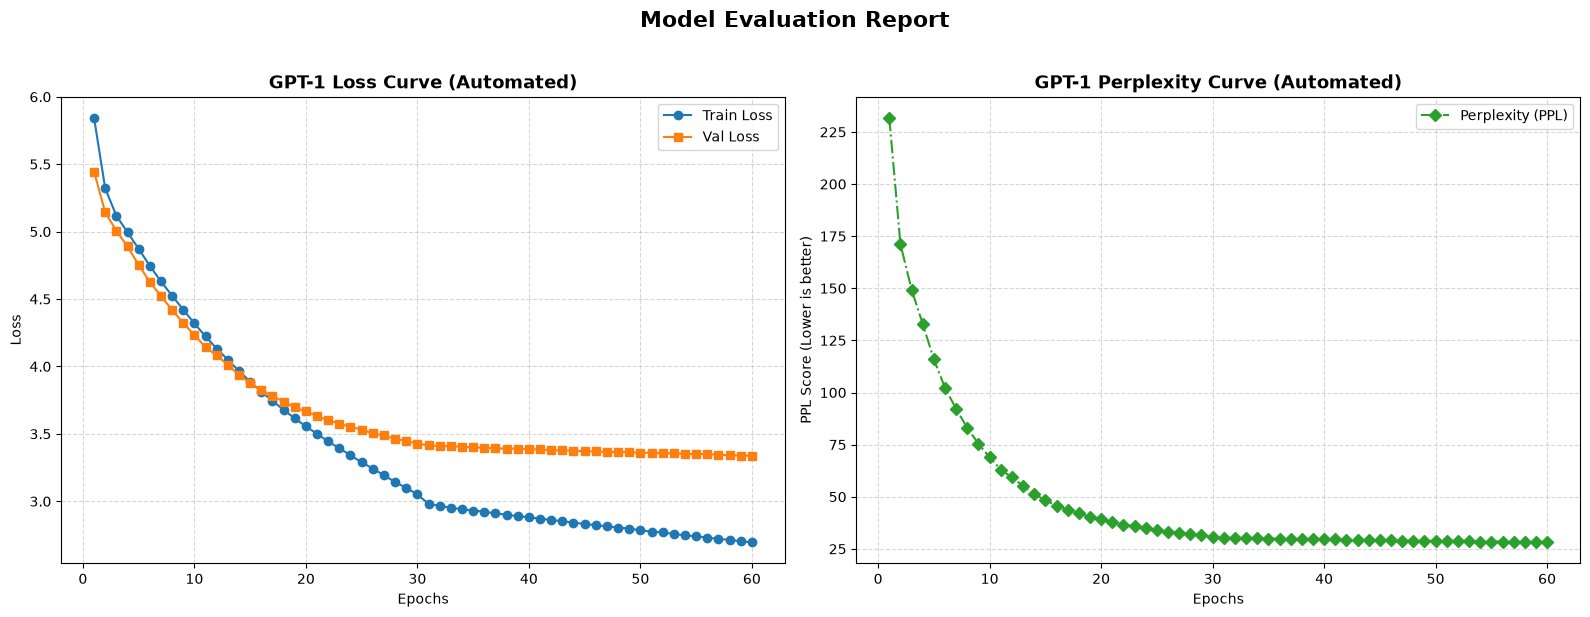

In [62]:
import matplotlib.pyplot as plt

save_dir = "./checkpoints"
epochs = []
train_losses = []
val_losses = []
ppl_values = [] # 자동 계산될 Perplexity 리스트

# 1. 디렉토리 내부의 모든 pt 파일을 탐색하여 수치를 자동으로 수집합니다.
# (31번부터 60번 에포크까지 자동으로 정렬하여 가져옵니다)
for epoch_idx in range(1, 61):
    checkpoint_path = os.path.join(save_dir, f"gpt1_epoch_{epoch_idx}.pt")
    
    if os.path.exists(checkpoint_path):
        # 로컬 세션 안정성을 위해 CPU로 가볍게 메타데이터만 로드
        checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        
        epochs.append(epoch_idx)
        train_losses.append(checkpoint['train_loss'])
        val_losses.append(checkpoint['val_loss'])
        
        # 🚀 Perplexity(PPL) 자동 계산: e^(Val Loss) 공식 적용
        current_ppl = math.exp(checkpoint['val_loss'])
        ppl_values.append(current_ppl)

# 최종 60 에포크 기준 수치 자동 추출 및 출력
if epochs:
    print("=== 📊 코드 자동 추출 최종 성적표 ===")
    print(f"최종 에포크: {epochs[-1]}")
    print(f"최종 Train Loss: {train_losses[-1]:.4f}")
    print(f"최종 Val Loss: {val_losses[-1]:.4f}")
    print(f"최종 Perplexity (PPL): {ppl_values[-1]:.2f} (다음 단어를 약 {int(ppl_values[-1])}개 중에서 정확히 압축!)")
    print("=" * 36)

    # 2. 2단 분할 그래프로 Loss와 PPL을 동시에 시각화
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # 왼쪽 그래프: 자동 Loss 곡선
    ax1.plot(epochs, train_losses, label='Train Loss', color='#1f77b4', marker='o')
    ax1.plot(epochs, val_losses, label='Val Loss', color='#ff7f0e', marker='s')
    ax1.set_title('GPT-1 Loss Curve (Automated)', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()

    # 오른쪽 그래프: 자동 Perplexity(PPL) 곡선
    ax2.plot(epochs, ppl_values, label='Perplexity (PPL)', color='#2ca02c', marker='D', linestyle='-.')
    ax2.set_title('GPT-1 Perplexity Curve (Automated)', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('PPL Score (Lower is better)')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()

    plt.suptitle('Model Evaluation Report', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # 로컬 경로에 자동 영구 저장
    plt.savefig(os.path.join(save_dir, 'automated_evaluation_report.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("❌ 체크포인트 폴더 내에 해당 에포크 파일이 존재하지 않습니다.")

맨처음 학습을 돌리고 나서 챗봇이 질문을 그대로 대답하는 현상이 있었습니다.  
기존 코드 : optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1) 
수정 코드 : optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)  
이 현상은 optimizer 부분에 lr 학습량 부분과 weight_decay 가중치 감쇠 부분을 10배 추가 해줬습니다.  
그 후 다시 학습을 진행하니 좋은 그래프를 그려줬습니다.  
기존 코드를 사용할 땐 에포크 4에서 가장 좋은 성능을 내고 그 이후로는 과적합 그래프가 그려졌지만  
수정 코드를 사용하고 나선 위에 그래프 처럼 60 에포크를 진행 했는데 과적합이 아직도 나오지 않았고  
61 에포크를 진행해도 아직 더 학습이 가능하다고 판단이 됩니다.  

코드는 9월 10일에 사용한 코드를 그대로 사용하여 gpt 1 에 맞게 변경만 시켰습니다.  
인코더로 들어오는 값 전부 교체하며 디코더 self로 변경했습니다.  
PositionwiseFeedForward 부분은 변경할 지점이 없어 그대로 사용 했습니다.  

weight_decay = 0.01 설정의 역할 : 옵티마이저가 가중치를 업데이트할 때마다, 가중치 크기의 일부(0.01배)만큼을 계속 강제로 깎아내립니다.